In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
from richio import shockfinder as sf
import nb, dev

## 1. Load snapshot

In [2]:
snap = richio.load('/home/hey4/rich_tde/data/raw/SedovDissipationGrad/sedov_100.h5')
snap.info()

                                     RICH SNAPSHOT INFORMATION                                      

Snapshot Details                        
----------------------------------------------------------------------------------------------------
  Path                      : /home/hey4/rich_tde/data/raw/SedovDissipationGrad/sedov_100.h5
  Snapshot Number           : -1
  Time                      : [0.0042907] code_time
  Box size                  : [-1. -1. -1.  1.  1.  1.] code_length
  Cycle                     : [100.] dimensionless
  Number of Cells           : 100,000
  Number of Ranks           : 1

Available Fields                         [Unit System: RICH]
----------------------------------------------------------------------------------------------------
Field           Unit                                     Aliases
----------------------------------------------------------------------------------------------------
Box             code_length                              box

/zfsstore/user/hey4/rich_tde/richio/richio/units.py:126: UserWarning: 'Eg_0' is in the data output but not used in the simulation.
  warnings.warn(f"'{key}' is in the data output but not used in the simulation.")


## 2. Build Voronoi graph

One-time cost per snapshot. Stores the adjacency in CSR format for fast numba traversal.

In [3]:
t0  = time.perf_counter()
vor = sf.build_voronoi(snap)
print(f'Built in {time.perf_counter()-t0:.1f} s')

Building Voronoi for 100,000 cells ...
Done.  Mean neighbours/cell: 14.7
Built in 4.4 s


## 3. Shock zone

Three criteria from Schaal+14 §2.1:
1. Converging flow: ∇·v < 0
2. Pressure gradient aligned with temperature gradient: ∇T·∇P > 0
3. Measurable T and P jump across the Voronoi face: Δlog T ≥ 0.11, Δlog P ≥ 0.27

In [4]:
t0         = time.perf_counter()
shock_zone = sf.find_shock_zone(snap, vor)
print(f'{shock_zone.sum():,} shock-zone cells  ({time.perf_counter()-t0:.2f} s)')

16,980 shock-zone cells  (4.54 s)


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


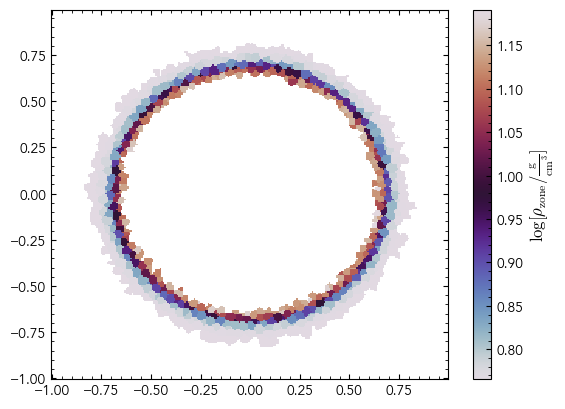

In [5]:
ax, im, _ = snap.plots.slice(snap.density * shock_zone,
                              res=256, label_latex=r'\rho_{\rm zone}')
plt.show()

## 4. Shock surface & Mach numbers

For each shock-zone cell, rays are traced along ±ds through the Voronoi graph
until exiting the zone. Mach numbers follow from the Rankine-Hugoniot T, P, ρ jumps.

In [6]:
t0     = time.perf_counter()
result = sf.find_shock_surface(snap, vor, shock_zone)
print(f'{result.surface_mask.sum():,} surface cells  ({time.perf_counter()-t0:.2f} s)')
print(f'Median Mach  T={np.median(result.mach_T):.2f}  P={np.median(result.mach_P):.2f}  rho={np.median(result.mach_rho):.2f}')

3,598 surface cells  (0.11 s)
Median Mach  T=186.49  P=144.08  rho=2.03


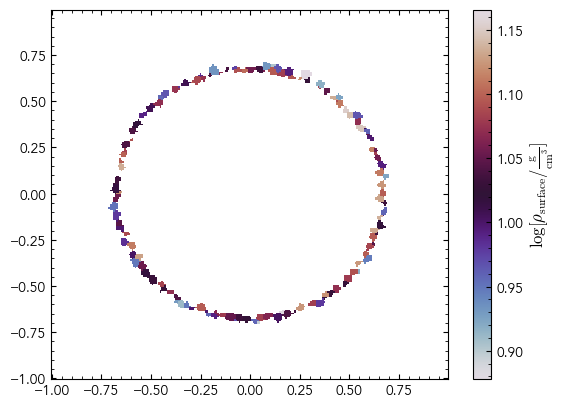

In [7]:
ax, im, _ = snap.plots.slice(snap.density * result.surface_mask,
                              res=256, label_latex=r'\rho_{\rm surface}')
plt.show()

## 5. Mach number distributions

M_T    n= 3598  finite= 3598  min=144.29  med=186.49  max=247.38
M_P    n= 3598  finite= 3598  min=105.07  med=144.08  max=157.20
M_rho  n= 3598  finite= 3598  min=1.20  med=2.03  max=2.73


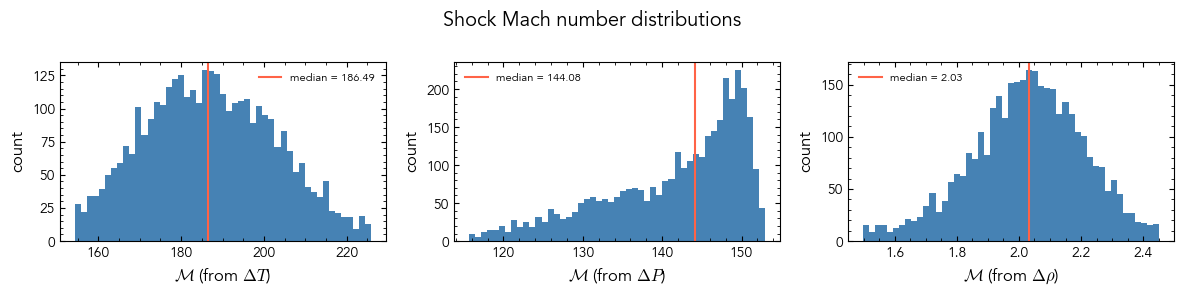

In [8]:

# Quick diagnostics — helps catch unit/scale surprises
for M, label in zip([result.mach_T, result.mach_P, result.mach_rho], ['T', 'P', 'rho']):
    finite = M[np.isfinite(M)]
    print(f'M_{label:3s}  n={len(M):5d}  finite={len(finite):5d}  '
          f'min={finite.min():.2f}  med={np.median(finite):.2f}  max={finite.max():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, M, label in zip(axes,
                         [result.mach_T, result.mach_P, result.mach_rho],
                         ['T', 'P', r'\rho']):
    finite = M[np.isfinite(M)]
    lo, hi = max(1, np.percentile(finite, 1)), np.percentile(finite, 99)
    bins   = np.linspace(lo, hi, 50)
    ax.hist(finite, bins=bins, color='steelblue', edgecolor='none')
    ax.axvline(np.median(finite), color='tomato', lw=1.5,
               label=f'median = {np.median(finite):.2f}')
    ax.set_xlabel(f'$\\mathcal{{M}}$ (from $\\Delta {label}$)')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
plt.suptitle('Shock Mach number distributions')
plt.tight_layout()
plt.show()


## 6. Voronoi cell view  (Schaal+14 Fig. 1 style)

Thin z-slab of the simulation projected onto the xy plane.
Each Voronoi cell is coloured by membership: ambient / shock zone / shock surface.

2323 cells in slab


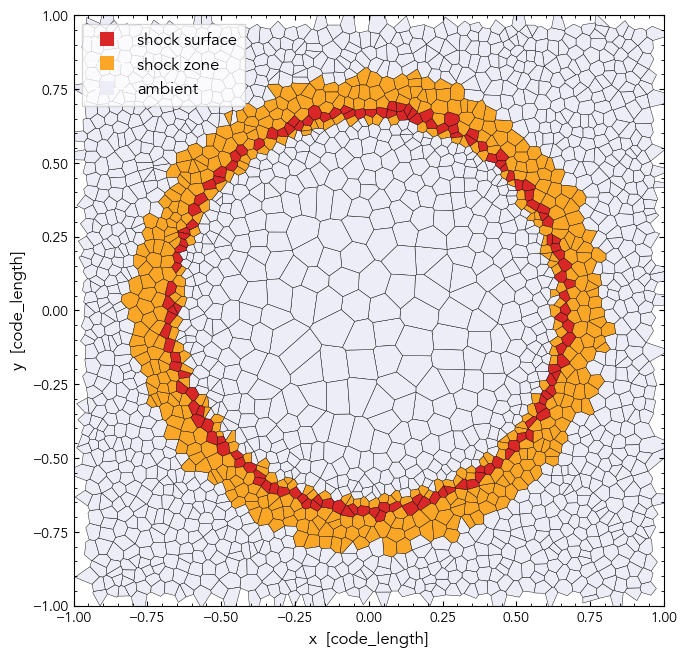

In [9]:

from scipy.spatial import Voronoi as Voronoi2D
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D

# thin z-slab — one quadrant around the shock ring
box  = snap.box.v
dz   = (box[5] - box[2]) / 80
x_lo, x_hi = box[0], box[3]
y_lo, y_hi = box[1], box[4]

x_v, y_v, z_v = snap.X.v, snap.Y.v, snap.Z.v
slab = (np.abs(z_v) < dz) & (x_v > x_lo) & (x_v < x_hi) & (y_v > y_lo) & (y_v < y_hi)
idx  = np.where(slab)[0]
print(f'{len(idx)} cells in slab')

vor2d = Voronoi2D(np.stack([x_v[idx], y_v[idx]], axis=-1))

patches, facecolors = [], []
for k, region_idx in enumerate(vor2d.point_region):
    region = vor2d.regions[region_idx]
    if -1 in region or len(region) == 0:
        continue
    verts = vor2d.vertices[region]
    # skip cells whose Voronoi vertices stray far outside the slab region
    if (verts[:, 0].min() < x_lo - 0.1*(x_hi-x_lo) or
            verts[:, 0].max() > x_hi + 0.1*(x_hi-x_lo) or
            verts[:, 1].min() < y_lo - 0.1*(y_hi-y_lo) or
            verts[:, 1].max() > y_hi + 0.1*(y_hi-y_lo)):
        continue
    gi = idx[k]
    if result.surface_mask[gi]:
        fc = (0.85, 0.15, 0.15)
    elif shock_zone[gi]:
        fc = (0.98, 0.65, 0.15)
    else:
        fc = (0.93, 0.93, 0.97)
    patches.append(Polygon(verts, closed=True))
    facecolors.append(fc)

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                   edgecolors='k', linewidths=0.3))
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_aspect('equal')
ax.set_xlabel('x  [code_length]')
ax.set_ylabel('y  [code_length]')
ax.legend(handles=[
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.85,0.15,0.15), markersize=10, label='shock surface'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.98,0.65,0.15), markersize=10, label='shock zone'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.93,0.93,0.97), markersize=10, label='ambient'),
], loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


## 6b. True 3D Voronoi slice at z = 0

Build the 3D Voronoi on a moderate z-slab, then intersect each Voronoi face (a 3D polygon) with the z = 0 plane to get line segments — this is the actual cross-section of the 3D tessellation rather than a 2D Voronoi re-tessellation of the projected points.

18776 cells in 3-D slab
3-D Voronoi built in 0.4 s
2658 cell cross-sections


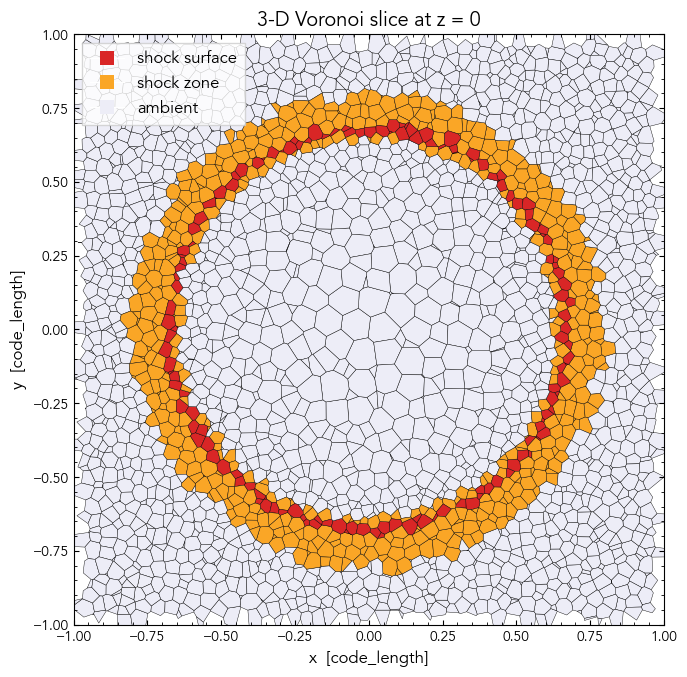

In [12]:

from scipy.spatial import Voronoi as Voronoi3D
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
from collections import defaultdict

# ── slab thick enough for proper 3-D neighbours ─────────────────────────────
box      = snap.box.v
dz_thick = (box[5] - box[2]) / 10
x_lo, x_hi = box[0], box[3]
y_lo, y_hi = box[1], box[4]

x_v, y_v, z_v = snap.X.v, snap.Y.v, snap.Z.v
slab3d = np.abs(z_v) < dz_thick
idx3d  = np.where(slab3d)[0]
print(f'{len(idx3d)} cells in 3-D slab')

pts3d = np.stack([x_v[idx3d], y_v[idx3d], z_v[idx3d]], axis=-1)

t0 = time.perf_counter()
vor3d = Voronoi3D(pts3d)
print(f'3-D Voronoi built in {time.perf_counter()-t0:.1f} s')

# ── membership ───────────────────────────────────────────────────────────────
def cell_rank(gi):
    if result.surface_mask[gi]: return 2
    if shock_zone[gi]:          return 1
    return 0

color_map = {2: (0.85, 0.15, 0.15),
             1: (0.98, 0.65, 0.15),
             0: (0.93, 0.93, 0.97)}

# ── collect z=0 intersection points per cell ────────────────────────────────
# Each Voronoi face that straddles z=0 contributes 2 boundary points to each
# of its two cells.  Gathering all such points per cell gives the vertices of
# that cell's cross-section polygon.
cell_xpts = defaultdict(list)
verts3d   = vor3d.vertices

for ridge_verts, (p0i, p1i) in zip(vor3d.ridge_vertices, vor3d.ridge_points):
    if -1 in ridge_verts:
        continue                       # unbounded face

    rv = verts3d[ridge_verts]
    zv = rv[:, 2]
    if zv.min() >= 0 or zv.max() <= 0:
        continue                       # face does not straddle z=0

    # order the convex face polygon around its centroid
    centroid = rv.mean(axis=0)
    normal   = pts3d[p1i] - pts3d[p0i]
    nlen     = np.linalg.norm(normal)
    if nlen == 0:
        continue
    normal /= nlen
    ref = np.array([1., 0., 0.]) if abs(normal[0]) < 0.9 else np.array([0., 1., 0.])
    u   = np.cross(normal, ref);  u /= np.linalg.norm(u)
    w   = np.cross(normal, u)
    rel = rv - centroid
    rv_ord = rv[np.argsort(np.arctan2(rel @ w, rel @ u))]

    # walk ordered edges, find z=0 crossings
    cross_pts = []
    n = len(rv_ord)
    for i in range(n):
        v0, v1 = rv_ord[i], rv_ord[(i + 1) % n]
        z0, z1 = v0[2], v1[2]
        if abs(z0) < 1e-14:
            cross_pts.append(v0[:2].copy())
        elif z0 * z1 < 0:
            t = z0 / (z0 - z1)
            cross_pts.append((v0 + t * (v1 - v0))[:2].copy())

    if len(cross_pts) >= 2:
        cell_xpts[p0i].extend(cross_pts)
        cell_xpts[p1i].extend(cross_pts)

# ── build polygon patches ────────────────────────────────────────────────────
patches, facecolors = [], []

for ci, pts in cell_xpts.items():
    pts_arr = np.unique(np.round(pts, 8), axis=0)   # deduplicate
    if len(pts_arr) < 3:
        continue

    cen    = pts_arr.mean(axis=0)
    angles = np.arctan2(pts_arr[:, 1] - cen[1], pts_arr[:, 0] - cen[0])
    pts_ord = pts_arr[np.argsort(angles)]

    # clip cells whose polygon strays well outside the box
    if (pts_ord[:, 0].min() < x_lo - 0.1 * (x_hi - x_lo) or
            pts_ord[:, 0].max() > x_hi + 0.1 * (x_hi - x_lo) or
            pts_ord[:, 1].min() < y_lo - 0.1 * (y_hi - y_lo) or
            pts_ord[:, 1].max() > y_hi + 0.1 * (y_hi - y_lo)):
        continue

    patches.append(Polygon(pts_ord, closed=True))
    facecolors.append(color_map[cell_rank(idx3d[ci])])

print(f'{len(patches)} cell cross-sections')

# ── plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                   edgecolors='k', linewidths=0.3))
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_aspect('equal')
ax.set_xlabel('x  [code_length]')
ax.set_ylabel('y  [code_length]')
ax.set_title('3-D Voronoi slice at z = 0')
ax.legend(handles=[
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.85,0.15,0.15), markersize=10, label='shock surface'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.98,0.65,0.15), markersize=10, label='shock zone'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=(0.93,0.93,0.97), markersize=10, label='ambient'),
], loc='upper left', frameon=True)
plt.tight_layout()
plt.show()
